In [1]:
import sys
from pathlib import Path

# Add repo root to path so utilities can be imported
repo_root = (
    str(Path(__file__).resolve().parent.parent) if "__file__" in dir() else str(Path.cwd().parent)
)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes

from utilities.datasets.paths import get_data_dir
from utilities.plots import with_default_styles

In [2]:
mle_results_dir = (
    get_data_dir() / "intermediate_data"
)  # signal_fitting_results_by_frequency.csv is here

# Load and explore datasets


In [3]:
# Load the MLE frequency scan results (high-resolution, iterative zoom)
freq_data_all = pd.read_csv(mle_results_dir / "signal_fitting_results_by_frequency.csv")

# Keep only the final iteration for each dataset
freq_data = freq_data_all[
    freq_data_all["iteration"]
    == freq_data_all.groupby("dataset_filename")["iteration"].transform("max")
].copy()

print("Frequency data shape:", freq_data.shape)
freq_data

Frequency data shape: (7000, 8)


,dataset_frequency_hz,dataset_filename,f_hz,fit_A_rad,fit_delta0_rad,fit_phi_rad,fit_logL,iteration
0,0.0001,excitation_fraction_corrected_signal-0_1mHz_63...,0.000070,0.004383,0.100531,0.752316,19627.532859,0
1,0.0001,excitation_fraction_corrected_signal-0_1mHz_63...,0.000070,0.004410,0.100533,2.967368,19627.759690,0
2,0.0001,excitation_fraction_corrected_signal-0_1mHz_63...,0.000070,0.004436,0.100534,-1.399153,19627.985343,0
3,0.0001,excitation_fraction_corrected_signal-0_1mHz_63...,0.000070,0.004462,0.100535,0.218940,19628.209679,0
4,0.0001,excitation_fraction_corrected_signal-0_1mHz_63...,0.000070,0.004488,0.100537,1.538270,19628.432561,0
...,...,...,...,...,...,...,...,...
13201,0.1000,excitation_fraction_corrected_signal-100mHz_64...,0.100081,0.001355,0.100285,2.516112,41055.080301,2
13202,0.1000,excitation_fraction_corrected_signal-100mHz_64...,0.100081,0.001376,0.100285,-1.294856,41055.194809,2
13204,0.1000,excitation_fraction_corrected_signal-100mHz_64...,0.100081,0.001396,0.100285,1.174182,41055.308375,2
13205,0.1000,excitation_fraction_corrected_signal-100mHz_64...,0.100081,0.001416,0.100285,-2.643146,41055.420782,2


In [4]:
unique_files = freq_data["dataset_filename"].unique()
unique_files

<StringArray>
[            'excitation_fraction_corrected_signal-0_1mHz_63483_63489_63668_63667_0.6.csv',
 'excitation_fraction_corrected_signal-0_3mHz_63846_63845_63844_63866_63868_63867_0.6.csv',
                           'excitation_fraction_corrected_signal-1mHz-again_65278_0.6.csv',
                     'excitation_fraction_corrected_signal-3mHz_63900_63902_63901_0.6.csv',
                                'excitation_fraction_corrected_signal-10mHz_64979_0.6.csv',
                                'excitation_fraction_corrected_signal-30mHz_65093_0.6.csv',
                               'excitation_fraction_corrected_signal-100mHz_64835_0.6.csv']
Length: 7, dtype: str

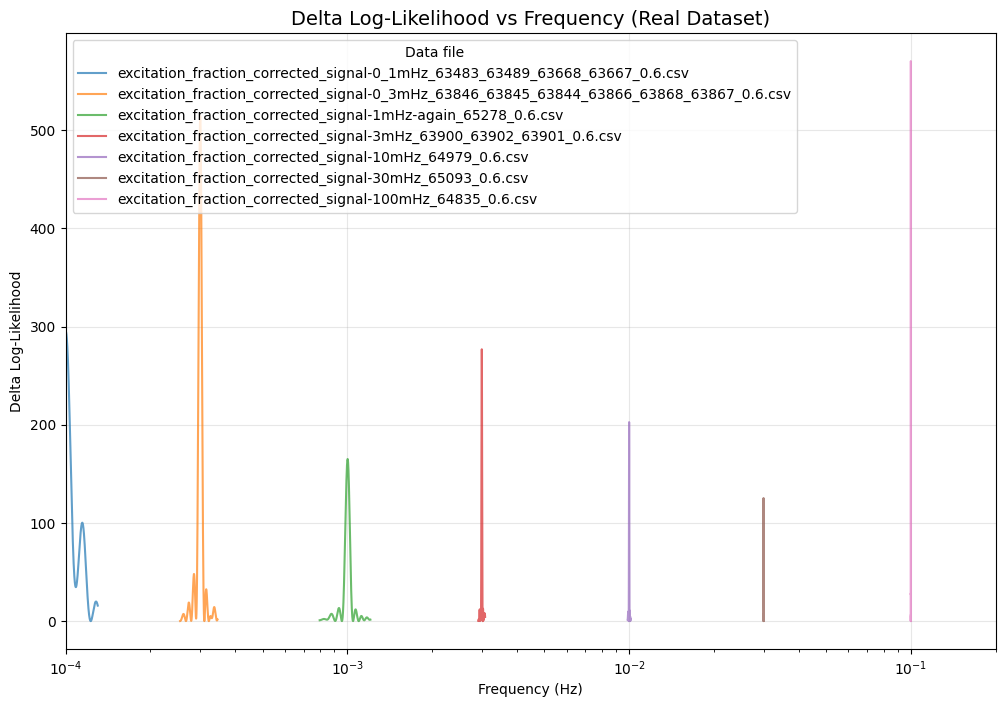

In [5]:
# Plot f_hz vs logL for real dataset, grouped by file
fig, ax = plt.subplots(figsize=(12, 8))


for i, file in enumerate(unique_files):
    file_data = freq_data[freq_data["dataset_filename"] == file]

    # Sort by frequency
    file_data = file_data.sort_values("f_hz")

    min_logL = file_data["fit_logL"].min()

    ax.semilogx(file_data["f_hz"], file_data["fit_logL"] - min_logL, "-", alpha=0.7, label=file)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Delta Log-Likelihood")
ax.set_title("Delta Log-Likelihood vs Frequency (Real Dataset)", fontsize=14)
ax.legend(title="Data file", fontsize=10, loc="best")
ax.set_xlim(1e-4, 200e-3)
ax.grid(True, alpha=0.3)

In [6]:
unique_files = freq_data["dataset_filename"].unique()

# Determine frequency ranges for each file based on peak width
xlims = []
file_xlims_dict = {}
xlim_metadata = {}
for file in unique_files:
    file_data = freq_data[freq_data["dataset_filename"] == file].sort_values("f_hz")

    # Find the peak
    peak_idx = file_data["fit_A_rad"].idxmax()
    peak_freq = file_data.loc[peak_idx, "f_hz"]
    peak_logL = file_data.loc[peak_idx, "fit_logL"]

    # Determine width: find half-maximum points
    half_max = peak_logL - (peak_logL - file_data["fit_logL"].min()) / 2

    # Find frequencies where logL crosses half-maximum
    above_half_max = file_data[file_data["fit_logL"] >= half_max]

    if len(above_half_max) > 1:
        f_min_hwhm = above_half_max["f_hz"].min()
        f_max_hwhm = above_half_max["f_hz"].max()
        fwhm = f_max_hwhm - f_min_hwhm
    else:
        # Fallback: use 10% of frequency range
        fwhm = (file_data["f_hz"].max() - file_data["f_hz"].min()) * 0.1

    # Set limits to ±5× the width, centered on peak
    width = 5 * fwhm
    xlim_range = (peak_freq - width, peak_freq + width)
    xlims.append(xlim_range)
    file_xlims_dict[file] = xlim_range
    xlim_metadata[xlim_range] = (peak_freq, fwhm)  # Store metadata for tick positioning

# Sort xlims by the lower bound to ensure proper ordering
xlims = sorted(xlims, key=lambda x: x[0])

In [7]:
# Load pre-computed true signal data (originally extracted via NDScanDataset.from_rid)
from utilities.analysis.signal_extraction import FrequencyExtractionResult

PRECOMPUTED_DIR = get_data_dir() / "precomputed_true_signals"

true_signal_stats = {}
for filename in unique_files:
    npz_name = f"signal_extraction_{Path(filename).stem}.npz"
    npz_path = PRECOMPUTED_DIR / npz_name
    data = np.load(npz_path)
    result = FrequencyExtractionResult(
        frequency=float(data["frequency"]),
        fitted_amplitude=float(data["fitted_amplitude"]),
        fitted_amplitude_err=float(data["fitted_amplitude_err"]),
        fitted_offset=float(data["fitted_offset"]),
        fitted_offset_err=float(data["fitted_offset_err"]),
        fitted_phase=float(data["fitted_phase"]),
        fitted_phase_err=float(data["fitted_phase_err"]),
        signal_mean=float(data["signal_mean"]),
        signal_amplitude=float(data["signal_amplitude"]),
        freqs=data["freqs"],
        pgram=data["pgram"],
    )
    true_signal_stats[filename] = result
    print(f"Loaded: {npz_name} -> freq={result.frequency * 1000:.3f} mHz")

Loaded: signal_extraction_excitation_fraction_corrected_signal-0_1mHz_63483_63489_63668_63667_0.6.npz -> freq=0.100 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-0_3mHz_63846_63845_63844_63866_63868_63867_0.6.npz -> freq=0.300 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-1mHz-again_65278_0.6.npz -> freq=1.000 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-3mHz_63900_63902_63901_0.6.npz -> freq=3.000 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-10mHz_64979_0.6.npz -> freq=10.000 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-30mHz_65093_0.6.npz -> freq=30.000 mHz
Loaded: signal_extraction_excitation_fraction_corrected_signal-100mHz_64835_0.6.npz -> freq=100.000 mHz


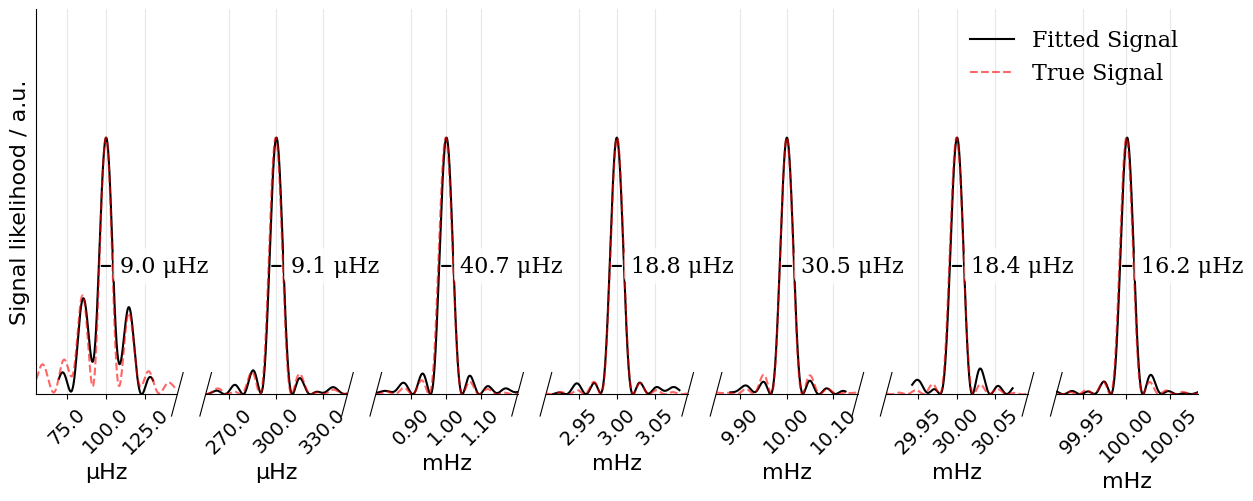

In [8]:
# Create broken axes figure
fig = plt.figure(figsize=(15, 5))
bax = brokenaxes(xlims=xlims, fig=fig, width_ratios=[1] * len(xlims), d=0.015, tilt=75.0)

color_fitted = "#000F"
color_true = "#F009"

with with_default_styles():
    # Plot each file's data, trimmed to its range
    for i, (file, ax) in enumerate(zip(unique_files, bax.axs)):
        # Set the axes' background to transparent
        ax.patch.set_alpha(0)

        true_signal_stats_for_file = true_signal_stats[file]

        file_data = freq_data[freq_data["dataset_filename"] == file].sort_values("f_hz")

        # Trim data to the xlims range for this file
        f_min, f_max = file_xlims_dict[file]
        file_data = file_data[(file_data["f_hz"] >= f_min) & (file_data["f_hz"] <= f_max)]

        # Plot the signal extracted from the interferometer
        min_logL = file_data["fit_logL"].min()
        freqs_interferometer, values_interferometer = (
            file_data["f_hz"].values,
            (file_data["fit_logL"] - min_logL).values,
        )
        # Normalize to unit peak height
        values_interferometer = values_interferometer / values_interferometer.max()

        handle_fitted = bax.plot(
            freqs_interferometer,
            values_interferometer,
            "-",
            color=color_fitted,
            label=file,
        )

        # Plot the true signal frequency extracted by periodogram
        freqs_true, values_true = (
            true_signal_stats_for_file.freqs,
            true_signal_stats_for_file.pgram,
        )
        # Trim to match xlims first
        k_mask = (freqs_true >= f_min) & (freqs_true <= f_max)
        freqs_true = freqs_true[k_mask]
        values_true = values_true[k_mask]
        # Normalize to unit peak height
        values_true_normalized = values_true / values_true.max()

        handle_true = bax.plot(
            freqs_true,
            values_true_normalized,
            "--",
            color=color_true,
            label=f"True Signal ({file})",
        )

        # Calculate FWHM of the fitted signal
        peak_value = values_interferometer.max()
        half_max = peak_value / 2

        # Find frequencies where signal crosses half-maximum
        above_half_max = values_interferometer >= half_max
        if above_half_max.any():
            ind_above = np.where(above_half_max)[0]
            if len(ind_above) > 1:
                f_min_hwhm = freqs_interferometer[ind_above[0]]
                f_max_hwhm = freqs_interferometer[ind_above[-1]]
                fwhm_fitted = f_max_hwhm - f_min_hwhm

                # Draw line at half-maximum height
                ax.annotate(
                    "",
                    xy=(f_max_hwhm, half_max),
                    xytext=(f_min_hwhm, half_max),
                    arrowprops=dict(arrowstyle="-", color="black", lw=1.5),
                )

                # Add FWHM text annotation next to the arrow
                # Determine appropriate units for annotation
                if fwhm_fitted < 5e-4:  # < 0.5 mHz, use μHz
                    fwhm_text = f"{1e6 * fwhm_fitted:.1f} μHz"
                else:  # >= 0.5 mHz, use mHz
                    fwhm_text = f"{1e3 * fwhm_fitted:.2f} mHz"

                # Position text to RHS of the arrow, left-aligned
                f_LHS = f_max_hwhm
                ax.text(
                    f_LHS + 0.5 * fwhm_fitted,
                    half_max,
                    fwhm_text,
                    horizontalalignment="left",
                    verticalalignment="center",
                    fontsize=16,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
                )

    # Format x-axis for each panel with appropriate units
    manual_xticks = {
        100e-6: (75e-6, 125e-6),
        300e-6: (270e-6, 330e-6),
        1e-3: (0.9e-3, 1.1e-3),
        3e-3: (2.95e-3, 3.05e-3),
        10e-3: (9.9e-3, 10.1e-3),
        30e-3: (29.95e-3, 30.05e-3),
        100e-3: (99.95e-3, 100.05e-3),
    }
    for i, (file, ax) in enumerate(zip(unique_files, bax.axs)):
        # Get the xlim to determine appropriate units
        x_min, x_max = ax.get_xlim()
        # Get peak and FWHM for this panel from the interferometry data
        peak_freq, fwhm = xlim_metadata[xlims[i]]
        # Get peak freq from the periodogram
        true_freq = true_signal_stats[file].frequency

        # Set exactly 3 x ticks, centred on the true frequency using manual xticks
        # Retrieve manual xticks for the frequency in manual_xticks closest to true_freq
        closest_key = min(manual_xticks.keys(), key=lambda k: abs(k - true_freq))
        xticks = manual_xticks[closest_key]
        ax.set_xticks([xticks[0], true_freq, xticks[1]])
        ax.tick_params(axis="x", labelsize=14)

        if x_max < 5e-4:  # < 0.5 mHz, use μHz
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{1e6 * x:.1f}"))
            ax.set_xlabel("μHz", fontsize=16)
        else:  # >= 0.5 mHz, use mHz
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{1e3 * x:.2f}"))
            ax.set_xlabel("mHz", fontsize=16)

        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)

    bax.set_ylabel("Signal likelihood / a.u.", fontsize=16, labelpad=4)
    for ax in bax.axs:
        ax.set_yticks([])
        ax.set_ylim([0, 1.5])

    bax.legend(
        [handle_fitted[0][0], handle_true[0][0]],
        [
            "Fitted Signal",
            "True Signal",
        ],
        frameon=False,
        loc="upper right",
        fontsize=16,
    )

plt.savefig("signal-fit-by-frequency.svg")
plt.savefig("signal-fit-by-frequency.pdf")

In [9]:
from openpyxl import Workbook

wb = Workbook()
wb.remove(wb.active)

for file in unique_files:
    stem = f"{true_signal_stats[file].frequency * 1000:.1f}mHz"
    ws = wb.create_sheet(stem)
    ws.append(["f_hz", "fitted_signal_normalized", "true_signal_normalized", "note"])

    true_stats = true_signal_stats[file]
    file_data = freq_data[freq_data["dataset_filename"] == file].sort_values("f_hz")
    f_min, f_max = file_xlims_dict[file]
    file_data = file_data[(file_data["f_hz"] >= f_min) & (file_data["f_hz"] <= f_max)]

    freqs_interferometer = file_data["f_hz"].values
    values_interferometer = (file_data["fit_logL"] - file_data["fit_logL"].min()).values
    values_interferometer = values_interferometer / values_interferometer.max()

    freqs_true = true_stats.freqs
    values_true = true_stats.pgram
    k_mask = (freqs_true >= f_min) & (freqs_true <= f_max)
    freqs_true = freqs_true[k_mask]
    values_true = values_true[k_mask]
    values_true_norm = values_true / values_true.max()

    # Calculate FWHM
    peak_value = values_interferometer.max()
    half_max = peak_value / 2
    above_half_max = values_interferometer >= half_max
    fwhm_text = ""
    if above_half_max.any():
        ind_above = np.where(above_half_max)[0]
        if len(ind_above) > 1:
            fwhm_fitted = freqs_interferometer[ind_above[-1]] - freqs_interferometer[ind_above[0]]
            if fwhm_fitted < 5e-4:
                fwhm_text = f"FWHM = {1e6 * fwhm_fitted:.1f} μHz"
            else:
                fwhm_text = f"FWHM = {1e3 * fwhm_fitted:.2f} mHz"

    max_len = max(len(freqs_interferometer), len(freqs_true))
    for i in range(max_len):
        row = [
            float(freqs_interferometer[i]) if i < len(freqs_interferometer) else None,
            float(values_interferometer[i]) if i < len(values_interferometer) else None,
            float(values_true_norm[i]) if i < len(freqs_true) else None,
            fwhm_text if i == 0 else None,
        ]
        ws.append(row)

wb.save("Figure_5a_data.xlsx")